<a href="https://colab.research.google.com/github/hulwene/DoAnML/blob/main/DenseNet_Workspace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

# Kết nối với Google Drive
drive.mount('/content/drive')

# Tạo thư mục dự án nếu chưa có và di chuyển vào đó
project_folder = '/content/drive/MyDrive/DenseNet_Project'
if not os.path.exists(project_folder):
    os.makedirs(project_folder)

%cd {project_folder}

Mounted at /content/drive
/content/drive/MyDrive/DenseNet_Project


In [2]:
import os

# 1. Tên repo và username của bạn
REPO_NAME = "DoAnML"

# 2. Tải toàn bộ code và file từ GitHub của bạn về Colab (nếu chưa tải)
if not os.path.exists(REPO_NAME):
    !git clone https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git

# 3. Di chuyển vào bên trong thư mục DoAnML (nơi chứa file requirements.txt)
%cd {REPO_NAME}

# 4. Lúc này Colab đã thấy file, tiến hành cài đặt thư viện
!pip install -r requirements.txt

# 5. Kiểm tra lại GPU
import torch
print(f"GPU đang sử dụng: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "Chưa bật GPU!")

/content/drive/MyDrive/DenseNet_Project/DoAnML
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
GPU đang sử dụng: Tesla T4


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import os

# Tạo thư mục chứa dữ liệu trong thư mục dự án DoAnML
data_dir = './data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# 1. Khai báo các phép biến đổi ảnh (Giống file transforms.lua của tác giả)
# Chuyển ảnh thành Tensor và chuẩn hóa màu sắc
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print("Đang tải bộ dữ liệu CIFAR-10 (Bộ dữ liệu mặc định của bài báo)...")

# 2. Tự động tải tập huấn luyện (Train set)
trainset = torchvision.datasets.CIFAR10(root=data_dir, train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

# 3. Tự động tải tập kiểm thử (Test set)
testset = torchvision.datasets.CIFAR10(root=data_dir, train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

print(f"Hoàn tất! Tổng số ảnh huấn luyện: {len(trainset)}, ảnh kiểm thử: {len(testset)}")

Đang tải bộ dữ liệu CIFAR-10 (Bộ dữ liệu mặc định của bài báo)...


100%|██████████| 170M/170M [00:15<00:00, 10.7MB/s]


Hoàn tất! Tổng số ảnh huấn luyện: 50000, ảnh kiểm thử: 10000


In [4]:
%%writefile data_loader.py
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os


def get_data_loaders(data_dir="./data", batch_size=64, num_workers=2):

    if not os.path.exists(data_dir):
        os.makedirs(data_dir)

    # Train augmenta (Shifting, mirroring)
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        )
    ])

    # Test (no augmentation)
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        )
    ])

    trainset = torchvision.datasets.CIFAR10(
        root=data_dir,
        train=True,
        download=True,
        transform=train_transform
    )

    testset = torchvision.datasets.CIFAR10(
        root=data_dir,
        train=False,
        download=True,
        transform=test_transform
    )

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )

    testloader = DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return trainloader, testloader


if __name__ == "__main__":
    trainloader, testloader = get_data_loaders()
    print(len(trainloader), len(testloader))

Writing data_loader.py


In [5]:
from data_loader import get_data_loaders

trainloader, testloader = get_data_loaders()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# 1. Cài đặt Device và số Epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 20

# 2. Khởi tạo mô hình DenseNet121 cho 10 class (CIFAR-10)
model = models.densenet121(num_classes=10)
model = model.to(device)

# 3. Hàm mất mát và Bộ tối ưu
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Cosine Annealing Scheduler (T_max đồng bộ với num_epochs)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print(f"✅ Đã khởi tạo mô hình trên thiết bị: {device}")

✅ Đã khởi tạo mô hình trên thiết bị: cuda


In [7]:
import os

# --- HÀM HUẤN LUYỆN 1 EPOCH ---
def train_one_epoch(model, trainloader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(trainloader), 100. * correct / total

# --- HÀM ĐÁNH GIÁ (TEST) ---
def evaluate(model, testloader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(testloader), 100. * correct / total

# --- HÀM LƯU CHECKPOINT ---
def save_checkpoint(model, optimizer, scheduler, epoch, path="/content/drive/MyDrive/DenseNet_Project/checkpoints"):
    os.makedirs(path, exist_ok=True)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict()
    }
    torch.save(checkpoint, f"{path}/model_epoch_{epoch}.pth")
    print(f"💾 Đã lưu Checkpoint an toàn tại epoch {epoch}")

In [8]:
# Mảng lưu lịch sử để vẽ biểu đồ
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

print("🚀 BẮT ĐẦU HUẤN LUYỆN...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 20)

    # Chạy Train và Test
    train_loss, train_acc = train_one_epoch(model, trainloader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, testloader, criterion)

    # Cập nhật tốc độ học
    scheduler.step()

    # Lưu lại kết quả
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f}  | Test  Acc: {test_acc:.2f}%")
    print(f"Learning Rate hiện tại: {scheduler.get_last_lr()[0]:.6f}")

    # Lưu model mỗi 5 epoch
    if (epoch + 1) % 5 == 0:
        save_checkpoint(model, optimizer, scheduler, epoch + 1)

print("\n🎉 HOÀN TẤT HUẤN LUYỆN!")

🚀 BẮT ĐẦU HUẤN LUYỆN...

Epoch 1/20
--------------------
Train Loss: 1.5202 | Train Acc: 44.54%
Test  Loss: 1.2406  | Test  Acc: 55.51%
Learning Rate hiện tại: 0.000994

Epoch 2/20
--------------------
Train Loss: 1.1448 | Train Acc: 59.35%
Test  Loss: 1.0645  | Test  Acc: 62.73%
Learning Rate hiện tại: 0.000976

Epoch 3/20
--------------------
Train Loss: 0.9739 | Train Acc: 65.84%
Test  Loss: 0.9482  | Test  Acc: 66.64%
Learning Rate hiện tại: 0.000946

Epoch 4/20
--------------------
Train Loss: 0.8527 | Train Acc: 70.19%
Test  Loss: 0.8205  | Test  Acc: 71.38%
Learning Rate hiện tại: 0.000905

Epoch 5/20
--------------------
Train Loss: 0.7652 | Train Acc: 73.34%
Test  Loss: 0.8028  | Test  Acc: 72.82%
Learning Rate hiện tại: 0.000854
💾 Đã lưu Checkpoint an toàn tại epoch 5

Epoch 6/20
--------------------
Train Loss: 0.6980 | Train Acc: 75.50%
Test  Loss: 0.6892  | Test  Acc: 75.78%
Learning Rate hiện tại: 0.000794

Epoch 7/20
--------------------
Train Loss: 0.6426 | Train Acc: 7

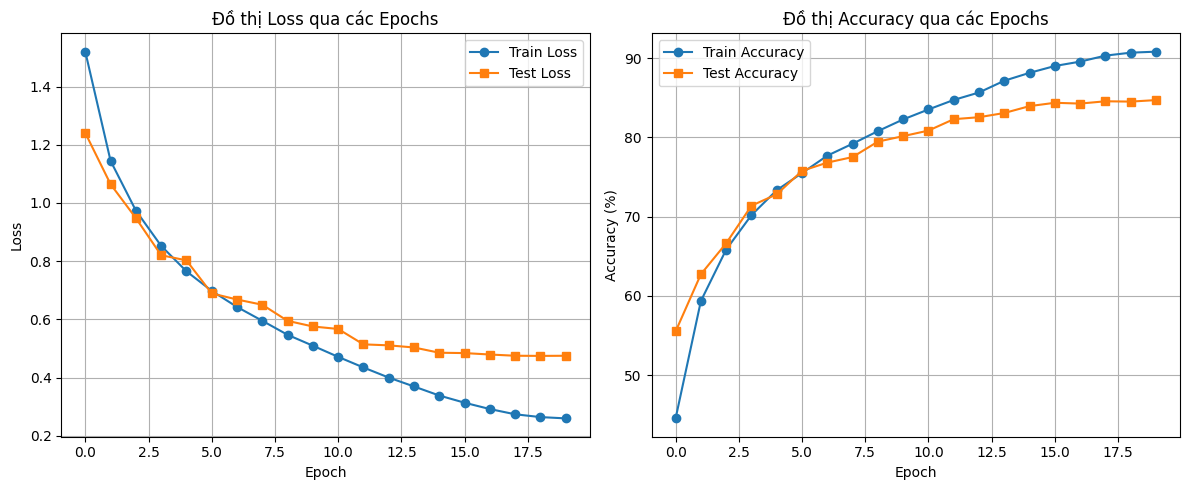

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(test_losses, label='Test Loss', marker='s')
plt.title("Đồ thị Loss qua các Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(test_accuracies, label='Test Accuracy', marker='s')
plt.title("Đồ thị Accuracy qua các Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()